
# ANN - Deep Learning - Concrete Compressive Strength  
# Regression & Classification Project <div align="center">
    
<div align="center">
    <img src="cementimage.jpg" width="700">
    
</div>
---

## Project Overview

This project focuses on predicting the compressive strength of concrete using:

- Conventional Machine Learning Algorithms
- Artificial Neural Networks (ANN)
- Deep Learning Models

The project contains two separate machine learning tasks:

###  Problem 1 — Regression
Predicting the numerical concrete compressive strength (MPa).

###  Problem 2 — Classification
Predicting the categorical concrete class for a given concrete recipe.

---

## Dataset Features

The dataset includes the following input variables:

- Cement
- Blast Furnace Slag
- Fly Ash
- Water
- Superplasticizer
- Coarse Aggregate
- Fine Aggregate
- Age

Target variables:
- Strength (Regression)
- ConcreteClass (Classification)

---

##  Project Objectives

- Data preprocessing
- Exploratory Data Analysis (EDA)
- Feature engineering
- Regression modeling
- Classification modeling
- Deep learning implementation
- Model comparison and evaluation

## Libraries Import

In [7]:
#pip install xlrd

Note: you may need to restart the kernel to use updated packages.


In [8]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [9]:
### Dataset reading
df = pd.read_excel("Concrete_Data.xls")

In [10]:
list(df.columns)

['Cement (component 1)(kg in a m^3 mixture)',
 'Blast Furnace Slag (component 2)(kg in a m^3 mixture)',
 'Fly Ash (component 3)(kg in a m^3 mixture)',
 'Water  (component 4)(kg in a m^3 mixture)',
 'Superplasticizer (component 5)(kg in a m^3 mixture)',
 'Coarse Aggregate  (component 6)(kg in a m^3 mixture)',
 'Fine Aggregate (component 7)(kg in a m^3 mixture)',
 'Age (day)',
 'Concrete compressive strength(MPa, megapascals) ']

In [11]:
df.columns = [
    'Cement',
    'Slag',
    'FlyAsh',
    'Water',
    'Plasticizer',
    'CoarseAgg',
    'FineAgg',
    'Age',
    'Strength']

In [12]:
df.head()

,Cement,Slag,FlyAsh,Water,Plasticizer,CoarseAgg,FineAgg,Age,Strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.986111
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.887366
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.269535
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.052780
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.296075


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1030 entries, 0 to 1029
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Cement       1030 non-null   float64
 1   Slag         1030 non-null   float64
 2   FlyAsh       1030 non-null   float64
 3   Water        1030 non-null   float64
 4   Plasticizer  1030 non-null   float64
 5   CoarseAgg    1030 non-null   float64
 6   FineAgg      1030 non-null   float64
 7   Age          1030 non-null   int64  
 8   Strength     1030 non-null   float64
dtypes: float64(8), int64(1)
memory usage: 72.6 KB


### EDA

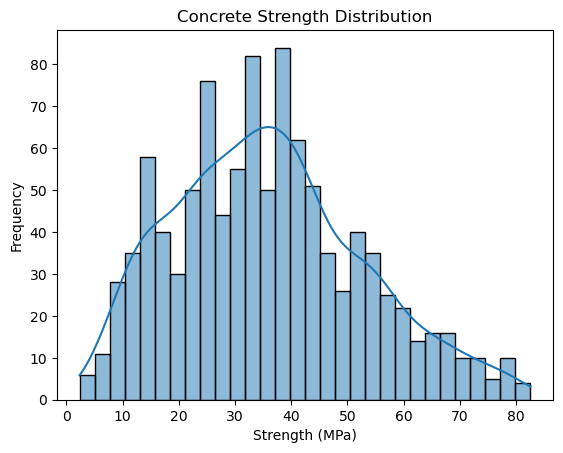

In [14]:
sns.histplot(
    df["Strength"],
    bins=30,
    kde=True)

plt.title("Concrete Strength Distribution")

plt.xlabel("Strength (MPa)")
plt.ylabel("Frequency")

plt.show()

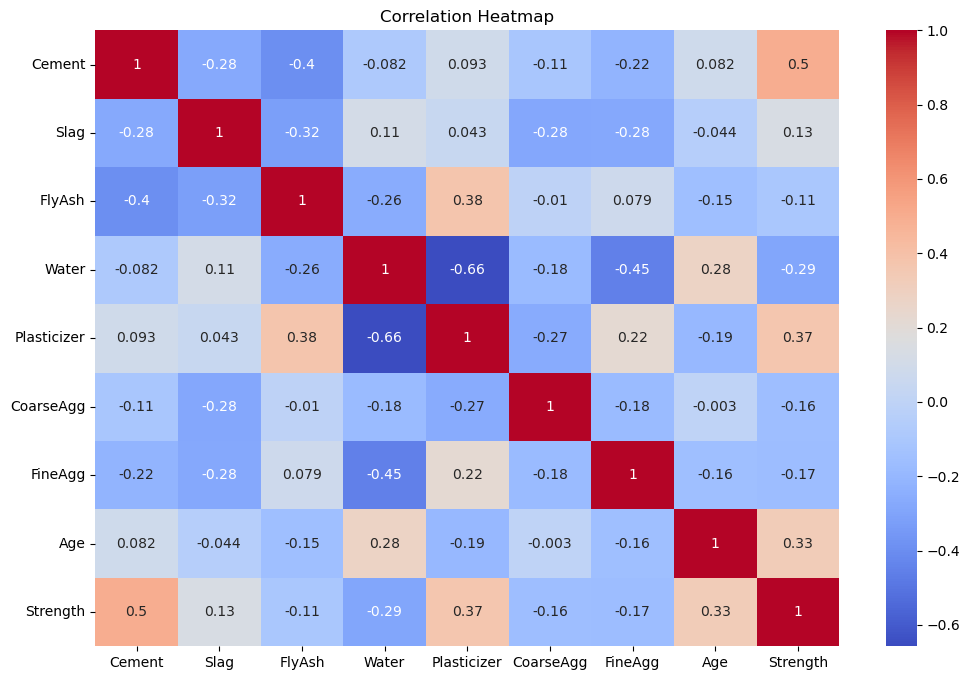

In [15]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

### # Correlation Heatmap Analysis

The heatmap shows the relationships between input variables and concrete compressive strength.

Key observations:
- Cement has the strongest positive correlation with Strength
- Plasticizer and Age also show positive relationships with Strength
- Water has a negative correlation with Strength
- No extreme multicollinearity was observed between input variables

These findings are consistent with real-world concrete engineering principles.

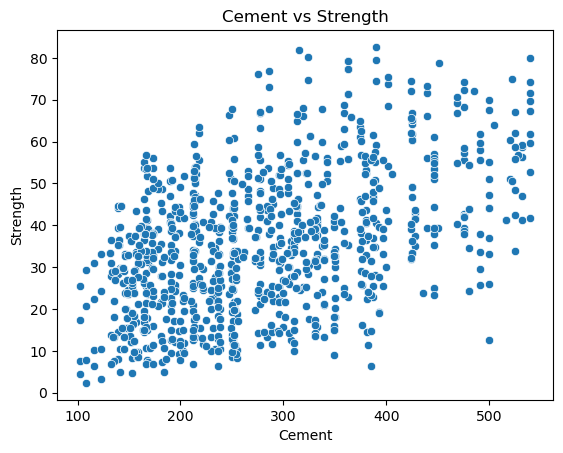

In [16]:
sns.scatterplot( x="Cement", y="Strength", data=df)
plt.title("Cement vs Strength")
plt.show()

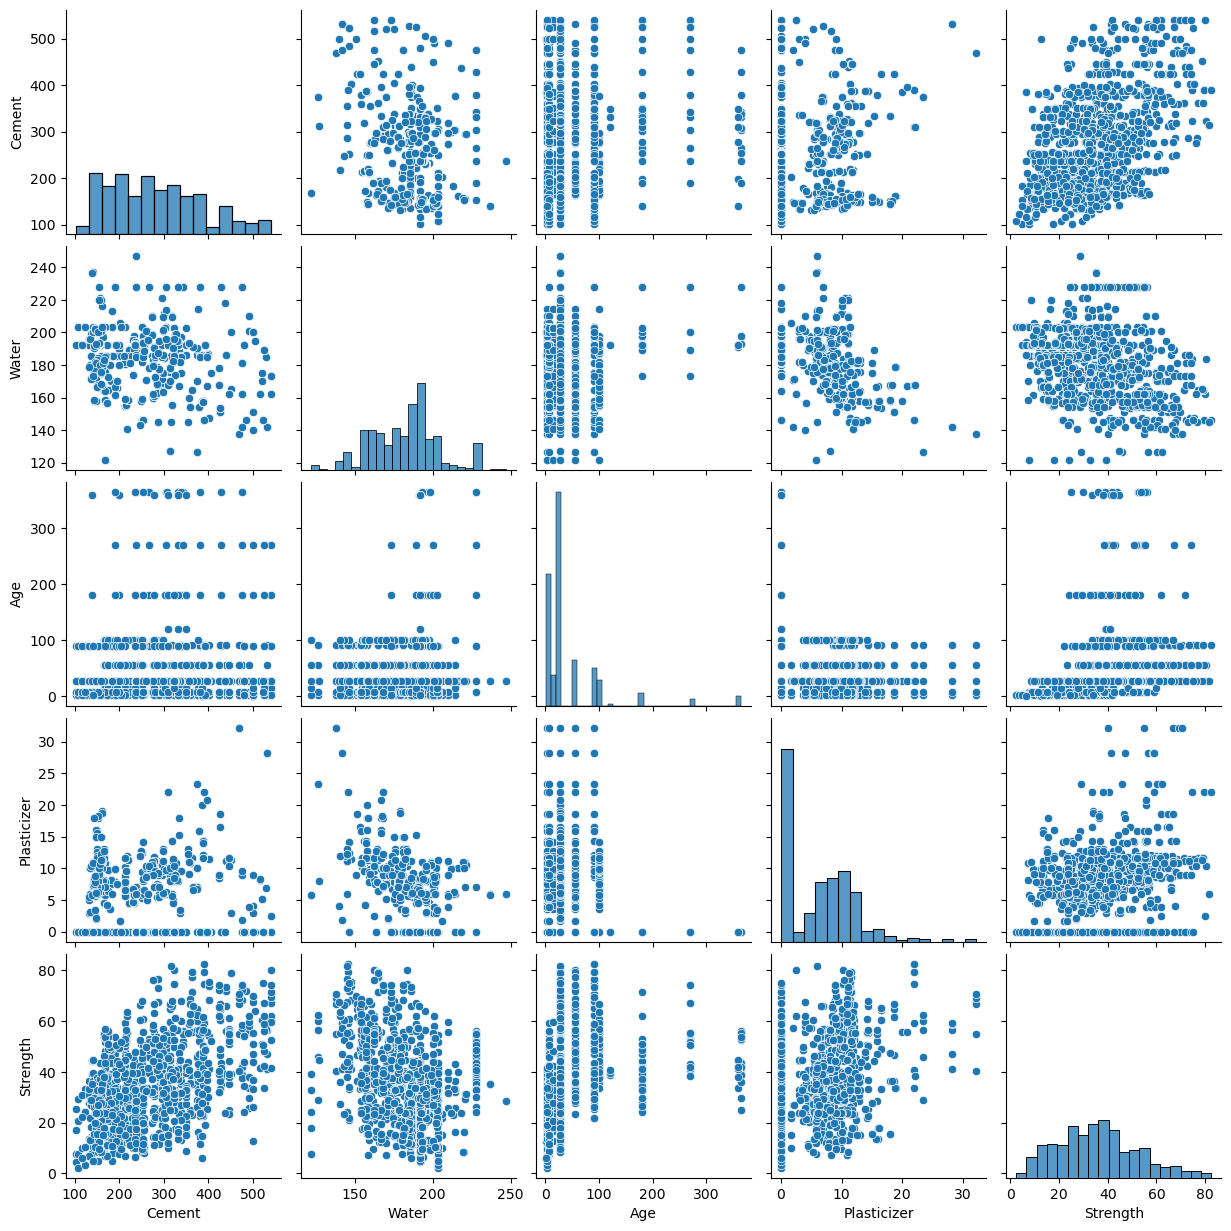

In [17]:
sns.pairplot(df[["Cement",
            "Water",
            "Age",
            "Plasticizer",
            "Strength"]])

plt.show()

### Regression

In [18]:
X = df.drop("Strength", axis=1)

y = df["Strength"]

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42)

In [20]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [21]:
from sklearn.linear_model import LinearRegression

In [22]:
lr_model = LinearRegression()

In [23]:
lr_model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [24]:
y_pred_lr = lr_model.predict(X_test)

In [25]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score)

In [26]:
mae = mean_absolute_error(y_test, y_pred_lr)

mse = mean_squared_error(y_test, y_pred_lr)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred_lr)

print("MAE :", mae)

print("MSE :", mse)

print("RMSE :", rmse)

print("R2 Score :", r2)

MAE : 7.745392872421345
MSE : 95.97548435337698
RMSE : 9.796707832398441
R2 Score : 0.6275416055429023


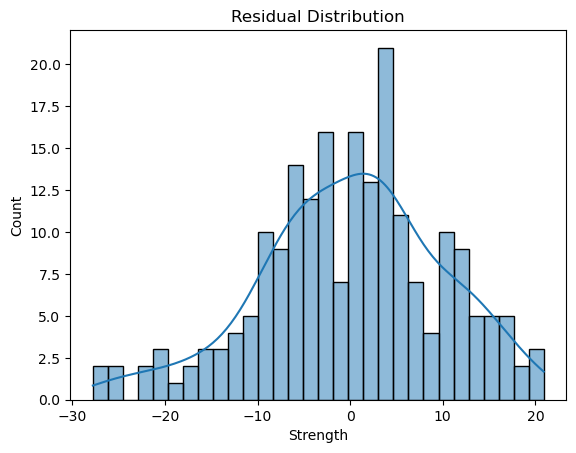

In [27]:
residuals = y_test - y_pred_lr
sns.histplot(
    residuals,
    bins=30,
    kde=True)

plt.title("Residual Distribution")

plt.show()

#  Linear Regression Evaluation

The Linear Regression model was used as a baseline regression model.

Results:
- MAE ≈ 7.75
- RMSE ≈ 9.80
- R² Score ≈ 0.63

The model explains approximately 63% of the variance in concrete compressive strength.

Although the model provides reasonable predictions, the performance is limited because concrete strength is influenced by complex nonlinear relationships between ingredients and curing age.

In [28]:
### Decision Tree Regressor
from sklearn.tree import DecisionTreeRegressor

In [29]:
dt_model = DecisionTreeRegressor(random_state=42)

In [30]:
dt_model.fit(X_train, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [31]:
y_pred_dt = dt_model.predict(X_test)

In [32]:
mae_dt = mean_absolute_error(y_test, y_pred_dt)

mse_dt = mean_squared_error(y_test, y_pred_dt)

rmse_dt = np.sqrt(mse_dt)

r2_dt = r2_score(y_test, y_pred_dt)

print("MAE :", mae_dt)

print("RMSE :", rmse_dt)

print("R2 Score :", r2_dt)

MAE : 4.5912651509848175
RMSE : 7.326202270512263
R2 Score : 0.7917067173788096


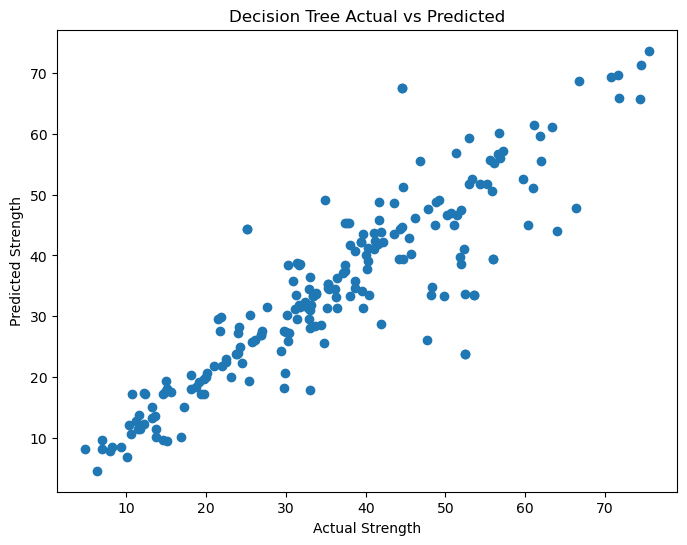

In [33]:
plt.figure(figsize=(8,6))
plt.scatter(y_test,y_pred_dt)
plt.xlabel("Actual Strength")
plt.ylabel("Predicted Strength")
plt.title("Decision Tree Actual vs Predicted")
plt.show()

# Decision Tree Regressor Evaluation

The Decision Tree Regressor significantly improved performance compared to the Linear Regression model.

Results:
- MAE ≈ 4.59
- RMSE ≈ 7.33
- R² Score ≈ 0.79

The model captured nonlinear relationships between concrete ingredients and compressive strength more effectively than Linear Regression.

This suggests that tree-based models are better suited for this dataset.

In [34]:
### Random Forest Regressor
from sklearn.ensemble import RandomForestRegressor

In [35]:
rf_model = RandomForestRegressor(n_estimators=100,random_state=42)

In [36]:
rf_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [37]:
y_pred_rf = rf_model.predict(X_test)

In [38]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)

mse_rf = mean_squared_error(y_test, y_pred_rf)

rmse_rf = np.sqrt(mse_rf)

r2_rf = r2_score(y_test, y_pred_rf)

print("MAE :", mae_rf)

print("RMSE :", rmse_rf)

print("R2 Score :", r2_rf)

MAE : 3.7581073324524428
RMSE : 5.5166685440337275
R2 Score : 0.8818941970097077


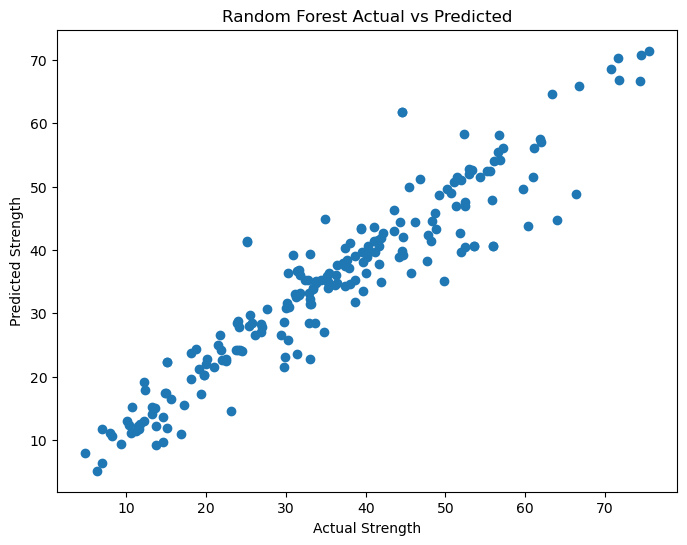

In [39]:
plt.figure(figsize=(8,6))
plt.scatter(y_test,y_pred_rf)
plt.xlabel("Actual Strength")
plt.ylabel("Predicted Strength")
plt.title("Random Forest Actual vs Predicted")
plt.show()

### Random Forest Regressor Evaluation

The Random Forest Regressor achieved the best performance among the tested regression models.

Results:
- MAE ≈ 3.76
- RMSE ≈ 5.52
- R² Score ≈ 0.88

The model successfully captured complex nonlinear relationships between concrete ingredients and compressive strength.

Random Forest provided highly accurate and stable predictions, making it one of the most suitable models for this dataset.

In [41]:
### Ridge Regression
from sklearn.linear_model import Ridge

ridge_model = Ridge()

ridge_model.fit(X_train, y_train)

y_pred_ridge = ridge_model.predict(X_test)

In [42]:
mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
mse_ridge = mean_squared_error(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mse_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)

print("MAE :", mae_ridge)
print("RMSE :", rmse_ridge)
print("R2 Score :", r2_ridge)

MAE : 7.751761421939313
RMSE : 9.796410930619144
R2 Score : 0.6275641808582496


In [43]:
### Lasso Regression
from sklearn.linear_model import Lasso

lasso_model = Lasso()

lasso_model.fit(X_train, y_train)

y_pred_lasso = lasso_model.predict(X_test)

In [44]:
mae_lasso = mean_absolute_error(y_test, y_pred_lasso)
mse_lasso = mean_squared_error(y_test, y_pred_lasso)
rmse_lasso = np.sqrt(mse_lasso)
r2_lasso = r2_score(y_test, y_pred_lasso)

print("MAE :", mae_lasso)
print("RMSE :", rmse_lasso)
print("R2 Score :", r2_lasso)

MAE : 8.716648876611394
RMSE : 10.60082875179278
R2 Score : 0.5638889487150622


In [45]:
from sklearn.neighbors import KNeighborsRegressor
knn_model = KNeighborsRegressor(n_neighbors=5)
knn_model.fit(X_train, y_train)
y_pred_knn = knn_model.predict(X_test)

In [46]:
mae_knn = mean_absolute_error(y_test, y_pred_knn)

mse_knn = mean_squared_error(y_test, y_pred_knn)

rmse_knn = np.sqrt(mse_knn)

r2_knn = r2_score(y_test, y_pred_knn)

print("MAE :", mae_knn)

print("RMSE :", rmse_knn)

print("R2 Score :", r2_knn)

MAE : 6.765328906961771
RMSE : 8.509829028544567
R2 Score : 0.7189658324141466


In [49]:
### Gradient Boosting Regressor
from sklearn.ensemble import GradientBoostingRegressor

gbr_model = GradientBoostingRegressor(
    random_state=42)

gbr_model.fit(X_train, y_train)

y_pred_gbr = gbr_model.predict(X_test)

In [50]:
mae_gbr = mean_absolute_error(y_test, y_pred_gbr)

mse_gbr = mean_squared_error(y_test, y_pred_gbr)

rmse_gbr = np.sqrt(mse_gbr)

r2_gbr = r2_score(y_test, y_pred_gbr)

print("MAE :", mae_gbr)

print("RMSE :", rmse_gbr)

print("R2 Score :", r2_gbr)

MAE : 4.102828088818279
RMSE : 5.544033704728977
R2 Score : 0.8807195749344955


### ANN — Deep Learning Regression Model

In [51]:
import tensorflow as tf

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import Dense

In [52]:
ann_model = Sequential()

In [53]:
ann_model.add(Dense(64,activation='relu',input_dim=X_train.shape[1]))
ann_model.add(Dense(32,activation='relu'))
ann_model.add(Dense(16,activation='relu'))

C:\Users\zbeun\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [54]:
ann_model.add(Dense(1))

In [55]:
ann_model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae'])

In [56]:
ann_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,201 (12.50 KB)

 Trainable params: 3,201 (12.50 KB)

 Non-trainable params: 0 (0.00 B)

In [57]:
history = ann_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    verbose=1)

Epoch 1/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 1519.6344 - mae: 35.0272 - val_loss: 1447.0529 - val_mae: 34.8329
Epoch 2/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1389.0195 - mae: 33.1735 - val_loss: 1269.0074 - val_mae: 32.2433
Epoch 3/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1132.3324 - mae: 29.2100 - val_loss: 925.3899 - val_mae: 26.6780
Epoch 4/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 709.6050 - mae: 21.6943 - val_loss: 451.4864 - val_mae: 17.2136
Epoch 5/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 327.3276 - mae: 14.3433 - val_loss: 198.8062 - val_mae: 11.5958
Epoch 6/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 235.8839 - mae: 12.2424 - val_loss: 170.0984 - val_mae: 10.9258
Epoch 7/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 215.6621 - mae: 11.7766 - val_loss: 165.6497 - val_mae: 10.7525
Epoch 8/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 203.7810 - mae: 11.5338 - val_loss: 163.6609 - val_mae: 10.7051
Epoch 9/10

In [58]:
y_pred_ann = ann_model.predict(X_test)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


In [59]:
mae_ann = mean_absolute_error(y_test, y_pred_ann)

mse_ann = mean_squared_error(y_test, y_pred_ann)

rmse_ann = np.sqrt(mse_ann)

r2_ann = r2_score(y_test, y_pred_ann)

print("MAE :", mae_ann)

print("RMSE :", rmse_ann)

print("R2 Score :", r2_ann)

MAE : 4.905666470541718
RMSE : 6.407239113813148
R2 Score : 0.8406840278218932


In [61]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Ridge Regression",
        "Lasso Regression",
        "KNN Regressor",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting",
        "ANN / Deep Learning"],

    "R2 Score": [r2,r2_ridge, r2_lasso,r2_knn,r2_dt,r2_rf,r2_gbr,r2_ann]})

results.sort_values(by="R2 Score",ascending=False)

,Model,R2 Score
5,Random Forest,0.881894
6,Gradient Boosting,0.880720
7,ANN / Deep Learning,0.840684
4,Decision Tree,0.791707
3,KNN Regressor,0.718966
1,Ridge Regression,0.627564
0,Linear Regression,0.627542
2,Lasso Regression,0.563889


# Final Regression Model Comparison

The regression results demonstrate that ensemble tree-based models achieved the highest prediction performance.

Key findings:
- Random Forest achieved the best overall performance
- Gradient Boosting produced very similar results
- ANN / Deep Learning also performed strongly
- Linear models showed lower prediction capability

These results confirm that concrete compressive strength is influenced by complex nonlinear relationships between ingredients and curing age.

Tree-based ensemble models were the most effective algorithms for this dataset.

### Problem 2 — Classification
ConcreteClass

In [62]:
def green_classifier(s):

    if (s.Slag + s.FlyAsh < 150.0) and (s.Plasticizer < 10.0):
        return "n/a"

    else:
        return "green"

In [63]:
def strength_classifer(x):

    if x < 17.0:
        return "non-structural"

    elif x < 28.0:
        return "residential"

    elif x < 70.0:
        return "commercial"

    else:
        return "high-strength"

In [64]:
df["Green"] = df.apply(
    green_classifier,
    axis=1)

df["ConcreteClass"] = df["Strength"].apply(
    strength_classifer)

In [65]:
df["Plasticizer"] = df["Plasticizer"].apply(
    lambda x: "yes" if x > 0 else "no")

In [68]:
df.columns

Index(['Cement', 'Slag', 'FlyAsh', 'Water', 'Plasticizer', 'CoarseAgg',
       'FineAgg', 'Age', 'Green', 'ConcreteClass'],
      dtype='object')

In [69]:
df["ConcreteClass"].value_counts()

ConcreteClass
commercial        633
residential       213
non-structural    148
high-strength      36
Name: count, dtype: int64

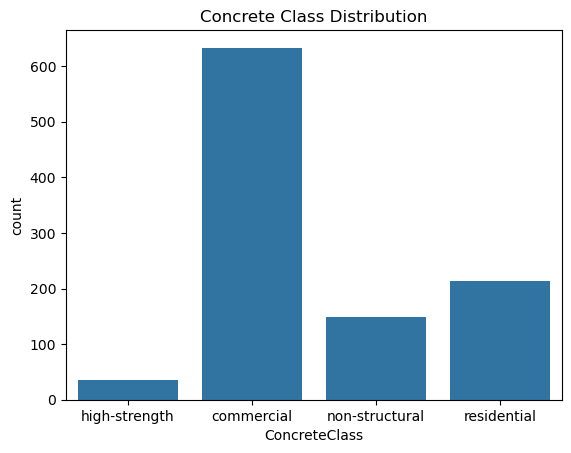

In [70]:
sns.countplot(x="ConcreteClass",data=df)
plt.title("Concrete Class Distribution")
plt.show()

###  Concrete Class Distribution Analysis

The class distribution shows a clear imbalance in the dataset.

Key observations:
- The majority of samples belong to the "commercial" class
- The "high-strength" class contains very few observations
- Minority classes may be more difficult for classification models to predict accurately

Therefore, evaluation metrics such as precision, recall, F1-score, and confusion matrix are important for model assessment.

In [71]:
### Logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [73]:
# Classification için X ve y yeniden oluştur
X = df.drop("ConcreteClass", axis=1)
y = df["ConcreteClass"]

In [74]:
# Kategorik feature'ları sayısala çevir
X = pd.get_dummies(X, drop_first=True)

In [75]:
# Target'ı sayısala çevir
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = le.fit_transform(y)

In [76]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y)

In [77]:
# Scaling
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [78]:
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)
y_pred_log = log_model.predict(X_test)

In [79]:
le.classes_

array(['commercial', 'high-strength', 'non-structural', 'residential'],
      dtype=object)

In [80]:
print("Accuracy:", accuracy_score(y_test, y_pred_log))

print(classification_report(y_test, y_pred_log, target_names=le.classes_))

Accuracy: 0.7864077669902912
                precision    recall  f1-score   support

    commercial       0.81      0.95      0.87       127
 high-strength       0.00      0.00      0.00         7
non-structural       0.78      0.83      0.81        30
   residential       0.67      0.38      0.48        42

      accuracy                           0.79       206
     macro avg       0.56      0.54      0.54       206
  weighted avg       0.75      0.79      0.75       206



C:\Users\zbeun\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\zbeun\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\zbeun\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


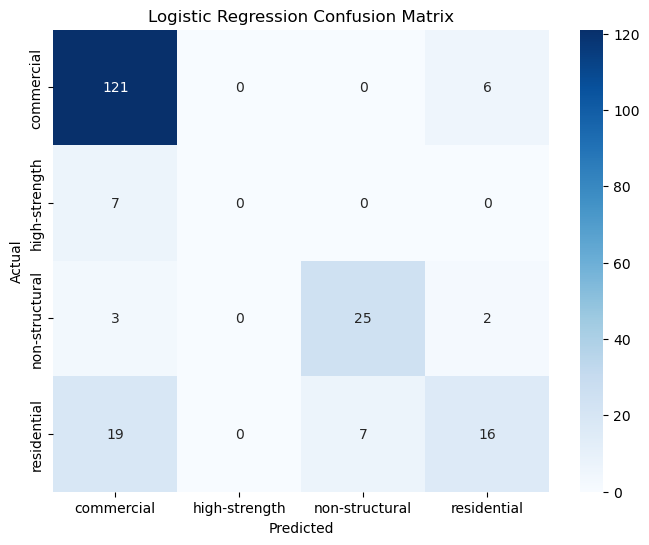

In [81]:
cm_log = confusion_matrix(y_test, y_pred_log)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm_log,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=le.classes_,
    yticklabels=le.classes_)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### Logistic Regression Confusion Matrix Analysis

The confusion matrix reveals that the Logistic Regression model performed well on the majority "commercial" class.

However:
- The model completely failed to classify the "high-strength" class
- Several "residential" samples were misclassified
- Minority classes were difficult to predict accurately

These results indicate that Logistic Regression struggles with imbalanced nonlinear classification problems.

### Decision Tree Classifier

In [82]:
from sklearn.tree import DecisionTreeClassifier

In [83]:
dtc_model = DecisionTreeClassifier(random_state=42)

In [84]:
dtc_model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [85]:
y_pred_dtc = dtc_model.predict(X_test)

In [86]:
print("Accuracy:",accuracy_score(y_test, y_pred_dtc))

Accuracy: 0.8155339805825242


In [87]:
print(classification_report(y_test,y_pred_dtc,target_names=le.classes_))

                precision    recall  f1-score   support

    commercial       0.91      0.93      0.92       127
 high-strength       1.00      0.57      0.73         7
non-structural       0.70      0.63      0.67        30
   residential       0.59      0.64      0.61        42

      accuracy                           0.82       206
     macro avg       0.80      0.69      0.73       206
  weighted avg       0.82      0.82      0.82       206



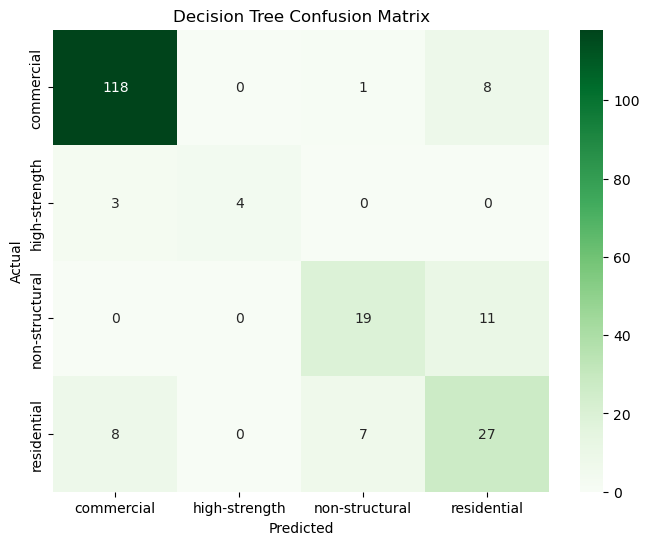

In [88]:
cm_dtc = confusion_matrix(y_test,y_pred_dtc)
plt.figure(figsize=(8,6))
sns.heatmap(
    cm_dtc,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=le.classes_,
    yticklabels=le.classes_)

plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### ### Decision Tree Classification Evaluation

The Decision Tree classifier improved overall classification performance compared to Logistic Regression.

Key observations:
- The model successfully identified some "high-strength" concrete samples
- Residential concrete classification improved significantly
- The model captured nonlinear relationships between concrete ingredients and class labels more effectively

Although the overall accuracy improved to approximately 81%, some class confusion still exists between residential and non-structural concrete categories.

### Random Forest Classifier

In [89]:
from sklearn.ensemble import RandomForestClassifier

In [90]:
rfc_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42)

In [91]:
rfc_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [92]:
y_pred_rfc = rfc_model.predict(X_test)

In [93]:
print("Accuracy:",accuracy_score(y_test, y_pred_rfc))

Accuracy: 0.8786407766990292


In [94]:
print(classification_report(y_test,y_pred_rfc,target_names=le.classes_))

                precision    recall  f1-score   support

    commercial       0.91      0.98      0.94       127
 high-strength       1.00      0.57      0.73         7
non-structural       0.85      0.73      0.79        30
   residential       0.78      0.74      0.76        42

      accuracy                           0.88       206
     macro avg       0.88      0.75      0.80       206
  weighted avg       0.88      0.88      0.87       206



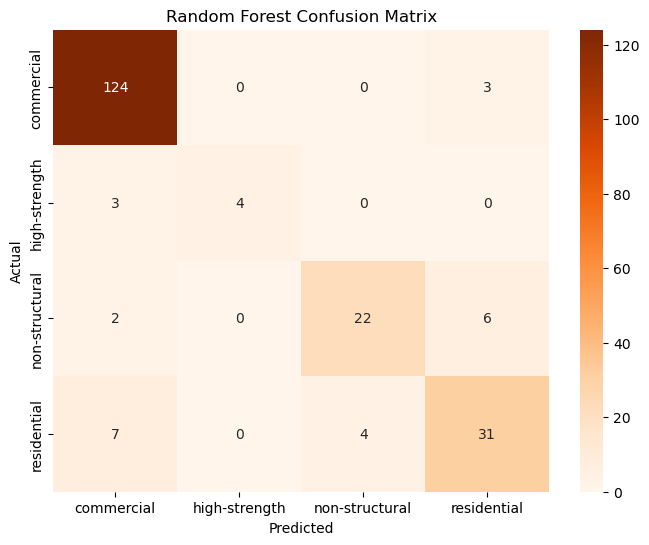

In [95]:
cm_rfc = confusion_matrix(
    y_test,
    y_pred_rfc)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm_rfc,
    annot=True,
    fmt='d',
    cmap='Oranges',
    xticklabels=le.classes_,
    yticklabels=le.classes_)

plt.title("Random Forest Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

### # Random Forest Classification Evaluation

The Random Forest classifier achieved the best overall classification performance among the tested models.

Key observations:
- The model achieved approximately 87% accuracy
- Commercial concrete samples were classified very accurately
- Minority classes such as "high-strength" were predicted better compared to Logistic Regression
- Random Forest successfully captured nonlinear relationships between concrete ingredients and concrete categories

The ensemble learning approach significantly improved classification stability and prediction performance.

### ANN / Deep Learning Classification

In [97]:
import tensorflow as tf

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import Dense

In [98]:
ann_clf = Sequential()

In [99]:
ann_clf.add(Dense(64,
        activation='relu',
        input_dim=X_train.shape[1]))
ann_clf.add(Dense(32,activation='relu'))
ann_clf.add(Dense(16,activation='relu'))

C:\Users\zbeun\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [100]:
ann_clf.add(Dense(4,activation='softmax'))

In [101]:
ann_clf.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'])

In [102]:
ann_clf.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 64)             │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 4)              │            68 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,316 (12.95 KB)

 Trainable params: 3,316 (12.95 KB)

 Non-trainable params: 0 (0.00 B)

In [103]:
history_clf = ann_clf.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    verbose=1)

Epoch 1/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.6039 - loss: 1.1028 - val_accuracy: 0.6182 - val_loss: 0.9974
Epoch 2/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6313 - loss: 0.9384 - val_accuracy: 0.6485 - val_loss: 0.8739
Epoch 3/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6586 - loss: 0.8534 - val_accuracy: 0.6727 - val_loss: 0.8121
Epoch 4/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6707 - loss: 0.7857 - val_accuracy: 0.6667 - val_loss: 0.7659
Epoch 5/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6798 - loss: 0.7289 - val_accuracy: 0.6788 - val_loss: 0.7326
Epoch 6/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7102 - loss: 0.6782 - val_accuracy: 0.7091 - val_loss: 0.6984
Epoch 7/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7436 - loss: 0.6387 - val_accuracy: 0.6970 - val_loss: 0.6730
Epoch 8/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7678 - loss: 0.6156 - val_accuracy: 0.7152 - 

In [104]:
y_pred_ann_clf = ann_clf.predict(X_test)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


In [105]:
y_pred_ann_clf = np.argmax(y_pred_ann_clf,axis=1)

In [106]:
print("Accuracy:",accuracy_score( y_test,y_pred_ann_clf))

Accuracy: 0.8300970873786407


In [107]:
print(classification_report(
        y_test,
        y_pred_ann_clf,
        target_names=le.classes_))

                precision    recall  f1-score   support

    commercial       0.89      0.94      0.91       127
 high-strength       0.80      0.57      0.67         7
non-structural       0.90      0.60      0.72        30
   residential       0.64      0.71      0.67        42

      accuracy                           0.83       206
     macro avg       0.81      0.71      0.74       206
  weighted avg       0.84      0.83      0.83       206



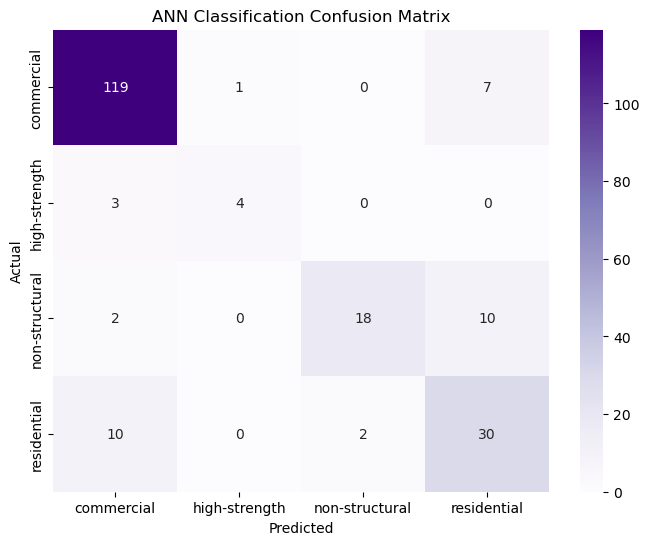

In [108]:
cm_ann = confusion_matrix(y_test,y_pred_ann_clf)
plt.figure(figsize=(8,6))
sns.heatmap(
    cm_ann,
    annot=True,
    fmt='d',
    cmap='Purples',
    xticklabels=le.classes_,
    yticklabels=le.classes_)

plt.title("ANN Classification Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

###  ANN Classification Evaluation

The ANN classification model achieved strong classification performance on the concrete dataset.

Key observations:
- Commercial concrete samples were classified accurately
- The model successfully identified some high-strength concrete samples
- ANN captured nonlinear relationships between concrete ingredients and concrete categories

Although the ANN model performed well, Random Forest achieved slightly better classification accuracy on this dataset.

In [110]:
classification_results = pd.DataFrame({"Model": ["Logistic Regression","Decision Tree","Random Forest","ANN / Deep Learning"],

    "Accuracy": [accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_dtc),
        accuracy_score(y_test, y_pred_rfc),
        accuracy_score(y_test, y_pred_ann_clf)]})

classification_results.sort_values(by="Accuracy",ascending=False)

,Model,Accuracy
2,Random Forest,0.878641
3,ANN / Deep Learning,0.830097
1,Decision Tree,0.815534
0,Logistic Regression,0.786408


### Final Conclusion

This project investigated both regression and classification approaches for predicting concrete compressive strength and concrete categories.

Key findings:
- Concrete compressive strength is a highly nonlinear problem
- Ensemble tree-based models achieved the best overall performance
- Random Forest provided the highest accuracy in both regression and classification tasks
- ANN / Deep Learning models also demonstrated strong predictive capability
- Linear models showed lower performance due to the nonlinear nature of the dataset

Overall, machine learning and deep learning methods successfully modeled the complex relationships between concrete ingredients, curing age, and concrete performance.